# Evaluate BEELINE network-sweep benchmark results

Computes precision / recall / F1 (plus AUPRC as a fully threshold-free metric) for every `rankedEdges.csv` produced by the BEELINE benchmark, against each dataset's `GroundTruthNetwork.csv`.

## Two threshold strategies -- computed and reported side by side

`rankedEdges.csv` is a *ranking*, not a binary prediction, so precision/recall/F1 need a cutoff. There isn't one universal cutoff that's fair to every algorithm, because algorithms differ in kind:

- **Top-k, tie-aware** -- for algorithms that output a genuine continuous ranking over the *full* edge space (e.g. correlation/MI scores for every possible pair). k = number of true edges in the ground truth (excluding self-loops); this mirrors BEELINE's own `EarlyPrecision` evaluator (`BLEval/EarlyPrecision.py`) exactly, including its tie-aware boundary (`best_val = max(smallest nonzero weight, weight of the k-th ranked edge)`, expanding to include all ties at that value rather than an arbitrary hard slice).
- **Natural / self-thresholded** -- for algorithms that internally make their own hard include/exclude decision and only assign a nonzero (or present) weight to edges they've decided are real (e.g. a significance test, or a fixed-size candidate-regulator list). Forcing these to the same top-k cutoff as the ground truth's edge count is unfair: a method that confidently outputs 6 edges when the true network has 17 shouldn't be penalized for not padding out to 17. This strategy just uses whatever the algorithm itself flagged as nonzero, with no truncation or padding.

Reporting both is also diagnostic: if an algorithm's two sets of numbers diverge a lot, that's a sign it's the "outputs its own fixed network" type rather than the "continuous ranking" type -- worth knowing regardless of which number you end up citing.

**AUPRC** (mirroring `BLEval/AUPRC.py`'s exact scoring-universe construction) is also computed as a fully threshold-free complementary metric.

In [22]:
import re
from itertools import combinations, permutations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import auc, precision_recall_curve

INPUT_ROOT = Path("/home/gzu5140/Keerthana_b1042/TwINFER/code/Beeline/inputs/network_sweep_final")
OUTPUT_ROOT = Path("/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/beeline_inference")
RESULTS_CSV = OUTPUT_ROOT / "evaluation_metrics.csv"

# Matches e.g. "simrep0_spread" -> sim_rep="0", scheme="spread" (network_sweep_final
# uses plain integer sim_reps, unlike cycle_6_node's hex hashes -- [0-9a-f]+ covers both)
RUN_ID_RE = re.compile(r"^simrep([0-9a-f]+)_(spread|twin_paired)$")

## Core evaluation logic

`build_edge_universe` and `top_k_tie_aware_selection` mirror `BLEval/EarlyPrecision.py`'s `_build_edge_universe`/`_compute_early_precision` exactly (directed non-self-loop gene pairs; `tf_edges=False`, appropriate for this synthetic data). `compute_auprc` mirrors `BLEval/AUPRC.py`'s `_compute_auprc` exactly. `natural_threshold_selection` is new -- there's no equivalent in `BLEval/`, since BEELINE itself only ever evaluates at the top-k cutoff.

In [23]:
def load_ground_truth(dataset_id: str) -> pd.DataFrame:
    # cycle_6_node uses one fixed topology for the whole sweep, so
    # GroundTruthNetwork.csv lives once directly under INPUT_ROOT rather than
    # being duplicated per dataset_id -- fall back to that shared copy.
    gt_path = INPUT_ROOT / dataset_id / "GroundTruthNetwork.csv"
    if not gt_path.exists():
        gt_path = INPUT_ROOT / "GroundTruthNetwork.csv"
    return pd.read_csv(gt_path, header=0)


def build_edge_universe(gt_df: pd.DataFrame):
    """All directed non-self-loop gene pairs among GT genes, and the true-edge subset."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    unique_nodes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = set(permutations(unique_nodes, 2))
    true_edges = set(zip(gt_no_self["Gene1"], gt_no_self["Gene2"])) & possible_edges
    return possible_edges, true_edges

def dedupe_predictions(ranked_edges: pd.DataFrame) -> pd.DataFrame:
    """Drop self-loops; keep the highest |EdgeWeight| per (Gene1, Gene2)."""
    pred = ranked_edges[ranked_edges["Gene1"] != ranked_edges["Gene2"]].copy()
    pred["_abs"] = pred["EdgeWeight"].abs()
    return (
        pred.sort_values("_abs", ascending=False)
        .drop_duplicates(subset=["Gene1", "Gene2"])
        .reset_index(drop=True)
    )


def top_k_tie_aware_selection(predicted: pd.DataFrame, num_true_edges: int):
    """
    Select the top-k predictions (k = num_true_edges), expanded to include all
    ties at the boundary weight -- same logic as
    BLEval.EarlyPrecision._compute_early_precision. Returns (selected_edge_set,
    threshold_weight_used).
    """
    if predicted.empty or num_true_edges == 0:
        return set(), float("nan")

    maxk = min(len(predicted), num_true_edges)
    edge_weight_topk = float(predicted.iloc[maxk - 1]["_abs"])

    nonzero = predicted.loc[predicted["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted[predicted["_abs"] >= best_val]
    return set(zip(selected["Gene1"], selected["Gene2"])), best_val


def natural_threshold_selection(predicted: pd.DataFrame):
    """
    Use whatever edges the algorithm itself assigned a nonzero weight to --
    no truncation or padding to match the ground truth's edge count. Fair to
    algorithms that make their own hard include/exclude decision (e.g. a
    significance test, or a fixed-size candidate-regulator list) rather than
    emitting a full continuous ranking meant to be externally truncated.
    """
    if predicted.empty:
        return set()
    selected = predicted[predicted["_abs"] > 0]
    return set(zip(selected["Gene1"], selected["Gene2"]))


def precision_recall_f1(selected_edges: set, true_edges: set):
    if not selected_edges:
        return 0.0, 0.0, 0.0
    tp = len(selected_edges & true_edges)
    precision = tp / len(selected_edges)
    recall = tp / len(true_edges) if true_edges else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def compute_auprc(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """Fully threshold-free complementary metric -- mirrors BLEval.AUPRC._compute_auprc exactly."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = list(permutations(gt_genes, 2))
    true_edge_set = set(zip(gt_df["Gene1"], gt_df["Gene2"]))

    pred = dedupe_predictions(ranked_edges)
    pred_lookup = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_abs"].astype(float)))

    true_labels = [1 if e in true_edge_set else 0 for e in possible_edges]
    pred_scores = [pred_lookup.get(e, 0.0) for e in possible_edges]

    if sum(true_labels) == 0:
        return float("nan")

    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))

## Two additional comparison strictness levels: signed+directed, and undirected+unsigned

The metrics above (`build_edge_universe`, `top_k_tie_aware_selection`, etc.) are directed but **sign-blind** -- a predicted `A->B` counts as correct regardless of whether the ground truth's `Type` (`+`/`-`) matches. Two more strictness levels bracket that:

- **Signed + directed** (`*_signed`) -- the strictest: a predicted edge only counts as correct if it matches the ground truth's `(Gene1, Gene2, Type)` exactly. Any mismatch -- wrong direction, wrong sign, or both -- is incorrect, full stop. For `auprc_signed` specifically: a wrong-sign prediction is scored as an **explicit false positive**, not merely an unscored miss. The scoring universe is every directed pair x both signs; a prediction's magnitude is only credited to the sign-position it actually predicted, so predicting `(A,B)` with the wrong sign shows up as a confident wrong answer at that rank (hurting precision), while the true `(A,B,true_sign)` position gets zero credit (a guaranteed miss for that edge) -- both consequences of the mismatch are real, not free.
- **Undirected + unsigned** (`*_undirected`) -- the most lenient: only "is there *any* relationship between these two genes" is evaluated. `(A,B)` and `(B,A)` collapse into one position (`frozenset({A,B})`), scored by whichever direction the algorithm ranked higher; sign is ignored entirely.

`n_true_edges_signed` and `n_true_edges_undirected` are computed separately per dataset (not assumed equal to the original `n_true_edges`), since a ground truth with any mutual/bidirectional regulation collapses to fewer undirected edges than directed ones.

**Partially available for TwINFER's fold-in rows below**: `twinfer_analysis_output.csv` now carries all three AUPRC levels (`auprc`, `auprc_signed`, `auprc_undirected`), computed in `network_sweep_analysis.ipynb` directly from each result JSON's `ranked_edge_list` (which has `directional_correlation`'s sign as the predicted sign) against the signed ground-truth matrix -- the same scoring-universe conventions as `compute_auprc_signed`/`compute_auprc_undirected` above. The `precision_topk_signed`/`recall_topk_signed`/etc. threshold-based columns are still `NaN` for TwINFER, since the summary CSV only carries directed, sign-blind TP/FP/FN/precision/recall/f1 (plus a `wrong_sign_edge` *count*, not a full re-derivable breakdown) -- there's no per-edge prediction set left to threshold at top-k or "natural" for the signed/undirected cases.

In [24]:
def build_signed_edge_universe(gt_df: pd.DataFrame):
    """Directed non-self-loop (Gene1, Gene2, Type) true-edge triples."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    true_signed_edges = set(zip(gt_no_self["Gene1"], gt_no_self["Gene2"], gt_no_self["Type"]))
    return true_signed_edges


def build_undirected_edge_universe(gt_df: pd.DataFrame):
    """All undirected non-self-loop gene pairs among GT genes (as frozensets), and the true subset."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    unique_nodes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_pairs = {frozenset(p) for p in combinations(unique_nodes, 2)}
    true_pairs = {frozenset((g1, g2)) for g1, g2 in zip(gt_no_self["Gene1"], gt_no_self["Gene2"])}
    return possible_pairs, true_pairs


def add_predicted_sign(predicted: pd.DataFrame) -> pd.DataFrame:
    """Attach a '+'/'-' predicted sign column derived from EdgeWeight's sign."""
    pred = predicted.copy()
    pred["_sign"] = np.where(pred["EdgeWeight"] >= 0, "+", "-")
    return pred


def top_k_tie_aware_selection_signed(predicted_signed: pd.DataFrame, num_true_edges: int):
    """Same top-k tie-aware boundary logic as top_k_tie_aware_selection, but selects and
    returns (Gene1, Gene2, predicted_sign) triples instead of (Gene1, Gene2) pairs."""
    if predicted_signed.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted_signed), num_true_edges)
    edge_weight_topk = float(predicted_signed.iloc[maxk - 1]["_abs"])
    nonzero = predicted_signed.loc[predicted_signed["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted_signed[predicted_signed["_abs"] >= best_val]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"])), best_val


def natural_threshold_selection_signed(predicted_signed: pd.DataFrame):
    if predicted_signed.empty:
        return set()
    selected = predicted_signed[predicted_signed["_abs"] > 0]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"]))


def compute_auprc_signed(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """
    AUPRC over directed AND signed edges. Scoring universe is every directed pair x both
    signs, so a wrong-signed prediction is scored as an explicit false positive (full
    magnitude credited to the *wrong* sign-position) rather than merely withheld -- see the
    markdown cell above for why.
    """
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = list(permutations(gt_genes, 2))
    possible_signed_positions = [(g1, g2, s) for (g1, g2) in possible_edges for s in ("+", "-")]

    true_signed_edges = build_signed_edge_universe(gt_df)

    pred = dedupe_predictions(ranked_edges)
    pred = add_predicted_sign(pred)
    pred_score_by_pair = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_abs"].astype(float)))
    pred_sign_by_pair = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_sign"]))

    true_labels, pred_scores = [], []
    for (g1, g2, s) in possible_signed_positions:
        true_labels.append(1 if (g1, g2, s) in true_signed_edges else 0)
        predicted_sign_here = pred_sign_by_pair.get((g1, g2))
        score = pred_score_by_pair.get((g1, g2), 0.0) if predicted_sign_here == s else 0.0
        pred_scores.append(score)

    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def dedupe_predictions_undirected(ranked_edges: pd.DataFrame) -> pd.DataFrame:
    """Drop self-loops; collapse (Gene1,Gene2) and (Gene2,Gene1) into one undirected edge
    (frozenset pair), keeping the highest |EdgeWeight| between the two directions."""
    pred = ranked_edges[ranked_edges["Gene1"] != ranked_edges["Gene2"]].copy()
    pred["_abs"] = pred["EdgeWeight"].abs()
    pred["_pair"] = [frozenset(p) for p in zip(pred["Gene1"], pred["Gene2"])]
    return (
        pred.sort_values("_abs", ascending=False)
        .drop_duplicates(subset=["_pair"])
        .reset_index(drop=True)
    )


def top_k_tie_aware_selection_undirected(predicted_undirected: pd.DataFrame, num_true_edges: int):
    if predicted_undirected.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted_undirected), num_true_edges)
    edge_weight_topk = float(predicted_undirected.iloc[maxk - 1]["_abs"])
    nonzero = predicted_undirected.loc[predicted_undirected["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted_undirected[predicted_undirected["_abs"] >= best_val]
    return set(selected["_pair"]), best_val


def natural_threshold_selection_undirected(predicted_undirected: pd.DataFrame):
    if predicted_undirected.empty:
        return set()
    selected = predicted_undirected[predicted_undirected["_abs"] > 0]
    return set(selected["_pair"])


def compute_auprc_undirected(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """AUPRC over undirected, unsigned edges -- only presence of a relationship is scored."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_pairs = [frozenset(p) for p in combinations(gt_genes, 2)]
    true_pairs = {frozenset((g1, g2)) for g1, g2 in zip(gt_df["Gene1"], gt_df["Gene2"])}

    pred = dedupe_predictions_undirected(ranked_edges)
    pred_lookup = dict(zip(pred["_pair"], pred["_abs"].astype(float)))

    true_labels = [1 if p in true_pairs else 0 for p in possible_pairs]
    pred_scores = [pred_lookup.get(p, 0.0) for p in possible_pairs]

    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))

## Discover and evaluate every rankedEdges.csv

In [25]:
rows = []

for dataset_dir in sorted(OUTPUT_ROOT.iterdir()):
    if not dataset_dir.is_dir():
        continue
    dataset_id = dataset_dir.name

    gt_path = INPUT_ROOT / dataset_id / "GroundTruthNetwork.csv"
    if not gt_path.exists():
        # Skips non-dataset directories under OUTPUT_ROOT, e.g. the sbatch
        # script's "logs/" dir for SLURM stdout/stderr, or evaluation_metrics.csv itself.
        continue

    gt_df = load_ground_truth(dataset_id)
    possible_edges, true_edges = build_edge_universe(gt_df)
    num_true_edges = len(true_edges)
    random_precision = num_true_edges / len(possible_edges) if possible_edges else float("nan")

    true_signed_edges = build_signed_edge_universe(gt_df)
    num_true_edges_signed = len(true_signed_edges)
    # signed universe is directed pairs x 2 signs -- see compute_auprc_signed
    random_precision_signed = num_true_edges_signed / (len(possible_edges) * 2) if possible_edges else float("nan")

    possible_pairs_undirected, true_pairs_undirected = build_undirected_edge_universe(gt_df)
    num_true_edges_undirected = len(true_pairs_undirected)
    random_precision_undirected = (
        num_true_edges_undirected / len(possible_pairs_undirected) if possible_pairs_undirected else float("nan")
    )

    for run_dir in sorted(dataset_dir.iterdir()):
        if not run_dir.is_dir():
            continue
        run_id = run_dir.name
        m = RUN_ID_RE.match(run_id)
        if not m:
            continue
        sim_rep, scheme = m.group(1), m.group(2)

        for algo_dir in sorted(run_dir.iterdir()):
            ranked_path = algo_dir / "rankedEdges.csv"
            if not ranked_path.exists():
                continue
            algorithm = algo_dir.name

            ranked_edges = pd.read_csv(ranked_path, sep="\t", header=0)
            predicted = dedupe_predictions(ranked_edges)

            selected_topk, threshold = top_k_tie_aware_selection(predicted, num_true_edges)
            p_topk, r_topk, f1_topk = precision_recall_f1(selected_topk, true_edges)
            epr = (p_topk / random_precision) if random_precision else float("nan")

            selected_nat = natural_threshold_selection(predicted)
            p_nat, r_nat, f1_nat = precision_recall_f1(selected_nat, true_edges)

            auprc = compute_auprc(ranked_edges, gt_df)

            # --- signed + directed: any mismatch (wrong direction or wrong sign) is incorrect ---
            predicted_signed = add_predicted_sign(predicted)

            selected_topk_signed, threshold_signed = top_k_tie_aware_selection_signed(
                predicted_signed, num_true_edges_signed
            )
            p_topk_s, r_topk_s, f1_topk_s = precision_recall_f1(selected_topk_signed, true_signed_edges)
            epr_signed = (p_topk_s / random_precision_signed) if random_precision_signed else float("nan")

            selected_nat_signed = natural_threshold_selection_signed(predicted_signed)
            p_nat_s, r_nat_s, f1_nat_s = precision_recall_f1(selected_nat_signed, true_signed_edges)

            auprc_signed = compute_auprc_signed(ranked_edges, gt_df)

            # --- undirected + unsigned: only presence of a relationship is considered ---
            predicted_undirected = dedupe_predictions_undirected(ranked_edges)

            selected_topk_und, threshold_und = top_k_tie_aware_selection_undirected(
                predicted_undirected, num_true_edges_undirected
            )
            p_topk_u, r_topk_u, f1_topk_u = precision_recall_f1(selected_topk_und, true_pairs_undirected)
            epr_undirected = (p_topk_u / random_precision_undirected) if random_precision_undirected else float("nan")

            selected_nat_und = natural_threshold_selection_undirected(predicted_undirected)
            p_nat_u, r_nat_u, f1_nat_u = precision_recall_f1(selected_nat_und, true_pairs_undirected)

            auprc_undirected = compute_auprc_undirected(ranked_edges, gt_df)

            rows.append({
                "dataset_id": dataset_id,
                "run_id": run_id,
                "sim_rep": sim_rep,
                "scheme": scheme,
                "algorithm": algorithm,
                "n_true_edges": num_true_edges,
                "n_selected_topk": len(selected_topk),
                "threshold_weight_topk": threshold,
                "precision_topk": p_topk,
                "recall_topk": r_topk,
                "f1_topk": f1_topk,
                "epr_topk": epr,
                "n_selected_natural": len(selected_nat),
                "precision_natural": p_nat,
                "recall_natural": r_nat,
                "f1_natural": f1_nat,
                "auprc": auprc,
                "n_true_edges_signed": num_true_edges_signed,
                "n_selected_topk_signed": len(selected_topk_signed),
                "threshold_weight_topk_signed": threshold_signed,
                "precision_topk_signed": p_topk_s,
                "recall_topk_signed": r_topk_s,
                "f1_topk_signed": f1_topk_s,
                "epr_topk_signed": epr_signed,
                "n_selected_natural_signed": len(selected_nat_signed),
                "precision_natural_signed": p_nat_s,
                "recall_natural_signed": r_nat_s,
                "f1_natural_signed": f1_nat_s,
                "auprc_signed": auprc_signed,
                "n_true_edges_undirected": num_true_edges_undirected,
                "n_selected_topk_undirected": len(selected_topk_und),
                "threshold_weight_topk_undirected": threshold_und,
                "precision_topk_undirected": p_topk_u,
                "recall_topk_undirected": r_topk_u,
                "f1_topk_undirected": f1_topk_u,
                "epr_topk_undirected": epr_undirected,
                "n_selected_natural_undirected": len(selected_nat_und),
                "precision_natural_undirected": p_nat_u,
                "recall_natural_undirected": r_nat_u,
                "f1_natural_undirected": f1_nat_u,
                "auprc_undirected": auprc_undirected,
            })

results = pd.DataFrame(rows)
results.to_csv(RESULTS_CSV, index=False)
print(f"Evaluated {len(results)} (dataset, run, algorithm) combinations.")
print(f"Saved to {RESULTS_CSV}")
results.head()

Evaluated 2053 (dataset, run, algorithm) combinations.
Saved to /home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/beeline_inference/evaluation_metrics.csv


,dataset_id,run_id,sim_rep,scheme,algorithm,n_true_edges,n_selected_topk,threshold_weight_topk,precision_topk,recall_topk,...,threshold_weight_topk_undirected,precision_topk_undirected,recall_topk_undirected,f1_topk_undirected,epr_topk_undirected,n_selected_natural_undirected,precision_natural_undirected,recall_natural_undirected,f1_natural_undirected,auprc_undirected
0,grn_n6_e17_pos100_density_rep0,simrep0_spread,0,spread,GENIE3,17,17,0.198044,0.529412,0.529412,...,0.198044,0.833333,0.833333,0.833333,1.041667,15,0.8,1.000000,0.888889,0.964194
1,grn_n6_e17_pos100_density_rep0,simrep0_spread,0,spread,GRNBOOST2,17,17,4.789297,0.588235,0.588235,...,4.876213,0.750000,0.750000,0.750000,0.937500,15,0.8,1.000000,0.888889,0.822398
2,grn_n6_e17_pos100_density_rep0,simrep0_spread,0,spread,PEARSON,17,18,0.012239,0.555556,0.588235,...,0.008462,0.750000,0.750000,0.750000,0.937500,15,0.8,1.000000,0.888889,0.785032
3,grn_n6_e17_pos100_density_rep0,simrep0_spread,0,spread,PIDC,17,18,1.098748,0.722222,0.764706,...,0.547933,0.833333,0.833333,0.833333,1.041667,15,0.8,1.000000,0.888889,0.929967
4,grn_n6_e17_pos100_density_rep0,simrep0_spread,0,spread,PPCOR,17,4,0.024419,0.750000,0.176471,...,0.024419,1.000000,0.166667,0.285714,1.250000,2,1.0,0.166667,0.285714,0.916667


## Fold in TwINFER's own inference results

`twinfer_analysis_output.csv` (built by `network_sweep_analysis.ipynb`'s `score_sweep_folder`) has TP/FP/FN/TN/precision/recall/f1 computed per (topology, sim_rep) from TwINFER's own hard include/exclude decision (`final_directed_edges`), plus all three AUPRC levels (`auprc`, `auprc_signed`, `auprc_undirected`), computed there from each result JSON's `ranked_edge_list` against the signed ground-truth matrix -- fully threshold-free, just like the BEELINE algorithms' AUPRC columns above.

It now also carries genuine top-k metrics at two strictness levels, both computed there by thresholding TwINFER's own `ranked_edge_list` (score = `|directional_correlation| + 1e-6*(1 - p_val)`, the same score `compute_twinfer_auprc` ranks by) at k = the ground-truth edge count, using the exact same tie-aware boundary logic as this notebook's `top_k_tie_aware_selection`/`top_k_tie_aware_selection_signed`:

- **Sign-blind, directed** -- `precision_topk`/`recall_topk`/`f1_topk`/`n_selected_topk`/`threshold_score_topk`, via `top_k_tie_aware_selection_twinfer`.
- **Directed AND signed (strictest)** -- `precision_topk_signed`/`recall_topk_signed`/`f1_topk_signed`/`n_selected_topk_signed`/`threshold_score_topk_signed`, via `top_k_tie_aware_selection_twinfer_signed`. Selection still uses the same magnitude-only ranking (sign never affects which edges clear the top-k cutoff); a selected edge only counts as a match if its predicted sign (sign of `directional_correlation`) also matches the ground truth.

So `precision_topk`/`recall_topk`/`f1_topk` and `precision_topk_signed`/`recall_topk_signed`/`f1_topk_signed` folded in below are a real top-k comparison against the BEELINE algorithms' own columns of the same name, not a copy of TwINFER's hard-decision precision/recall/f1 -- `f1_topk`/`f1_topk_signed` and `f1_natural`/`f1_natural_signed` can now genuinely diverge for TwINFER, the same signal the Notes cell below calls out for other "outputs its own fixed network" algorithms.

The `_natural` and `_natural_signed` columns still reflect TwINFER's hard decision (`final_directed_edges` + `direction_matrix` sign) unchanged -- fair, since that's the prediction TwINFER actually commits to, with no truncation or padding to the ground truth's edge count.

**Undirected top-k selection is not implemented on the TwINFER side** (only directed top-k, sign-blind and signed), so the `*_topk_undirected`/`*_natural_undirected` threshold-based columns stay `NaN`, same as before.

In [26]:
TWINFER_CSV = Path("/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/twinfer_analysis_output.csv")
TWINFER_REP_RE = re.compile(r"rep(\d+)_rep(\d+)")

twinfer_df = pd.read_csv(TWINFER_CSV)
twinfer_rows = []

for _, row in twinfer_df.iterrows():
    dataset_id = row["matched_topology_file"].replace(".txt", "")
    m = TWINFER_REP_RE.search(row["json_file"])
    sim_rep = m.group(2) if m else None

    gt_df = load_ground_truth(dataset_id)
    possible_edges, _ = build_edge_universe(gt_df)

    # --- sign-blind (directed only) ---
    num_true_edges = int(row["TP"] + row["FN"])
    random_precision = num_true_edges / len(possible_edges) if possible_edges else float("nan")
    # precision_topk/recall_topk/f1_topk/n_selected_topk/threshold_score_topk are now
    # real top-k metrics, computed in network_sweep_analysis.ipynb's
    # top_k_tie_aware_selection_twinfer by thresholding TwINFER's own ranked_edge_list
    # at k = num_true_edges with the same tie-aware boundary logic as this notebook's
    # top_k_tie_aware_selection -- NaN if that JSON has no ranked_edge_list.
    epr_topk = (row["precision_topk"] / random_precision) if random_precision else float("nan")
    n_selected_natural = int(row["TP"] + row["FP"])

    # --- directed AND signed (strictest) ---
    num_true_edges_signed = int(row["TP_signed"] + row["FN_signed"])
    # signed universe is directed pairs x 2 signs -- matches
    # random_precision_signed's convention in the discovery-loop cell above
    random_precision_signed = (
        num_true_edges_signed / (len(possible_edges) * 2) if possible_edges else float("nan")
    )
    # precision_topk_signed/recall_topk_signed/f1_topk_signed/n_selected_topk_signed/
    # threshold_score_topk_signed are also real top-k metrics now, computed in
    # network_sweep_analysis.ipynb's top_k_tie_aware_selection_twinfer_signed --
    # the same magnitude-only ranking/threshold as the sign-blind top-k above, but a
    # selected edge only counts as a match if its predicted sign also matches the
    # ground truth.
    epr_topk_signed = (row["precision_topk_signed"] / random_precision_signed) if random_precision_signed else float("nan")
    epr_signed = (row["precision_signed"] / random_precision_signed) if random_precision_signed else float("nan")
    n_selected_natural_signed = int(row["TP_signed"] + row["FP_signed"])

    twinfer_rows.append({
        "dataset_id": dataset_id,
        "run_id": f"simrep{sim_rep}_twinfer",
        "sim_rep": sim_rep,
        "scheme": "twinfer",
        "algorithm": "TwINFER",
        "n_true_edges": num_true_edges,
        "n_selected_topk": row["n_selected_topk"],
        "threshold_weight_topk": row["threshold_score_topk"],
        "precision_topk": row["precision_topk"],
        "recall_topk": row["recall_topk"],
        "f1_topk": row["f1_topk"],
        "epr_topk": epr_topk,
        "n_selected_natural": n_selected_natural,
        "precision_natural": row["precision"],
        "recall_natural": row["recall"],
        "f1_natural": row["f1"],
        # All three AUPRC levels, computed in network_sweep_analysis.ipynb's
        # score_sweep_folder from each result JSON's ranked_edge_list (which
        # carries directional_correlation's sign as the predicted sign) against
        # the signed ground-truth matrix -- fully threshold-free, unlike the
        # precision/recall/f1 columns above. NaN for any row whose JSON predates
        # ranked_list=True.
        "auprc": row["auprc"],
        "n_true_edges_signed": num_true_edges_signed,
        "n_selected_topk_signed": row["n_selected_topk_signed"],
        "threshold_weight_topk_signed": row["threshold_score_topk_signed"],
        "precision_topk_signed": row["precision_topk_signed"],
        "recall_topk_signed": row["recall_topk_signed"],
        "f1_topk_signed": row["f1_topk_signed"],
        "epr_topk_signed": epr_topk_signed,
        "n_selected_natural_signed": n_selected_natural_signed,
        "precision_natural_signed": row["precision_signed"],
        "recall_natural_signed": row["recall_signed"],
        "f1_natural_signed": row["f1_signed"],
        "auprc_signed": row["auprc_signed"],
        # Undirected/unsigned TP/FP/FN/precision/recall/f1 aren't computed by
        # score_directed_edges at all (only the AUPRC-level undirected metric
        # has a TwINFER-side counterpart, via compute_twinfer_auprc_undirected),
        # and there's no undirected top-k selection on the TwINFER side either,
        # so these threshold-based columns stay NaN -- see the markdown cell
        # above "Two additional comparison strictness levels".
        "n_true_edges_undirected": float("nan"),
        "n_selected_topk_undirected": float("nan"),
        "threshold_weight_topk_undirected": float("nan"),
        "precision_topk_undirected": float("nan"),
        "recall_topk_undirected": float("nan"),
        "f1_topk_undirected": float("nan"),
        "epr_topk_undirected": float("nan"),
        "n_selected_natural_undirected": float("nan"),
        "precision_natural_undirected": float("nan"),
        "recall_natural_undirected": float("nan"),
        "f1_natural_undirected": float("nan"),
        "auprc_undirected": row["auprc_undirected"],
    })

results = pd.concat([results, pd.DataFrame(twinfer_rows)], ignore_index=True)
results.to_csv(RESULTS_CSV, index=False)
print(f"Added {len(twinfer_rows)} TwINFER rows. results now has {len(results)} total rows.")


Added 250 TwINFER rows. results now has 2303 total rows.


## Cap every dataset to 10 replicates, common to every method

Some algorithms (GENIE3 in particular) silently fail on a handful of sim_reps for a
handful of datasets, which -- left unfixed -- means different algorithms would be
averaged over different, unequal sets of replicate files for the same dataset (e.g.
GENIE3 averaged over 5 reps while every other method got 8). That's not a fair
comparison. This cell restricts every (dataset, algorithm) pair to the same 10
sim_reps -- specifically, the intersection of sim_reps present for *every*
algorithm on that dataset, sorted numerically and capped at 10. Datasets where
that intersection is naturally below 10 (because some algorithm is missing more
than 0 reps) fall back to using all of the common reps that do exist -- there's no
way to conjure a 10th shared file that was never produced -- and are called out
explicitly below so it's visible rather than silently averaging over fewer reps.

In [27]:
MAX_REPS_PER_DATASET = 10

def _select_common_reps(df: pd.DataFrame, max_reps: int = MAX_REPS_PER_DATASET):
    """Restrict every (dataset_id, algorithm) group to the same `max_reps` sim_reps --
    the intersection of sim_reps available across every algorithm for that dataset,
    sorted numerically and capped at max_reps. Returns (filtered_df, per-dataset summary)."""
    kept_frames = []
    summary_rows = []
    for dataset_id, ds_df in df.groupby("dataset_id"):
        rep_sets = [set(g["sim_rep"].astype(str)) for _, g in ds_df.groupby("algorithm")]
        common = set.intersection(*rep_sets) if rep_sets else set()
        try:
            common_sorted = sorted(common, key=int)
        except ValueError:
            common_sorted = sorted(common)
        selected = common_sorted[:max_reps]
        summary_rows.append({
            "dataset_id": dataset_id,
            "n_common_reps": len(common_sorted),
            "n_selected_reps": len(selected),
        })
        kept_frames.append(ds_df[ds_df["sim_rep"].astype(str).isin(selected)])
    summary_df = pd.DataFrame(summary_rows)
    return pd.concat(kept_frames, ignore_index=True), summary_df


results, rep_selection_summary = _select_common_reps(results)

short = rep_selection_summary[rep_selection_summary["n_selected_reps"] < MAX_REPS_PER_DATASET]
if not short.empty:
    print(f"{len(short)} dataset(s) have fewer than {MAX_REPS_PER_DATASET} sim_reps common to every algorithm "
          "-- using all common reps available for those instead:")
    print(short.to_string(index=False))

results.to_csv(RESULTS_CSV, index=False)
print(f"\nAfter capping to {MAX_REPS_PER_DATASET} common reps: {len(results)} rows across "
      f"{results['dataset_id'].nunique()} datasets.")

4 dataset(s) have fewer than 10 sim_reps common to every algorithm -- using all common reps available for those instead:
                    dataset_id  n_common_reps  n_selected_reps
grn_n6_e17_pos100_density_rep0              9                9
grn_n6_e17_pos100_density_rep1              7                7
grn_n6_e17_pos100_density_rep2              5                5
 grn_n6_e5_pos100_density_rep2              8                8

After capping to 10 common reps: 2142 rows across 15 datasets.


## Summary table: mean metrics per algorithm x scheme

Averaged across all datasets and simulation replicates. `n_selected_natural` close to `n_true_edges` on average means that algorithm's own natural output size happens to land near the ground truth's edge count -- worth checking before trusting the top-k numbers for it in isolation.

In [28]:
summary = (
    results.groupby(["algorithm", "scheme"])[[
        "precision_topk", "recall_topk", "f1_topk", "epr_topk",
        "precision_natural", "recall_natural", "f1_natural",
        "n_selected_natural", "n_true_edges", "auprc",
        "precision_topk_signed", "recall_topk_signed", "f1_topk_signed", "auprc_signed",
        "precision_topk_undirected", "recall_topk_undirected", "f1_topk_undirected", "auprc_undirected",
    ]]
    .mean()
    .round(3)
    .sort_values("f1_topk", ascending=False)
)
summary

precision_topk  recall_topk  f1_topk  epr_topk  \
algorithm scheme                                                        
TwINFER   twinfer               0.678        0.678    0.678     2.507   
PEARSON   spread                0.459        0.510    0.483     1.547   
          twin_paired           0.452        0.502    0.476     1.516   
PIDC      twin_paired           0.444        0.493    0.467     1.465   
          spread                0.432        0.479    0.454     1.412   
PPCOR     twin_paired           0.508        0.447    0.439     1.674   
          spread                0.517        0.434    0.436     1.699   
GRNBOOST2 twin_paired           0.415        0.415    0.415     1.366   
          spread                0.409        0.409    0.409     1.349   
SCSGL     twin_paired           0.363        0.402    0.381     1.161   
          spread                0.357        0.395    0.375     1.140   
SCODE     spread                0.318        0.318    0.318     0.982   
          twin_paired           0.302        0.302    0.302     0.924   
GENIE3    spread                0.278        0.278    0.278     0.815   
          twin_paired           0.269        0.269    0.269     0.790   

                       precision_natural  recall_natural  f1_natural  \
algorithm scheme                                                       
TwINFER   twinfer                  0.739           0.487       0.506   
PEARSON   spread                   0.313           1.000       0.466   
          twin_paired              0.313           1.000       0.466   
PIDC      twin_paired              0.313           0.982       0.463   
          spread                   0.314           0.983       0.465   
PPCOR     twin_paired              0.483           0.569       0.457   
          spread                   0.505           0.575       0.470   
GRNBOOST2 twin_paired              0.313           1.000       0.466   
          spread                   0.313           1.000       0.466   
SCSGL     twin_paired              0.318           0.955       0.464   
          spread                   0.313           0.944       0.458   
SCODE     spread                   0.313           1.000       0.466   
          twin_paired              0.313           1.000       0.466   
GENIE3    spread                   0.313           1.000       0.466   
          twin_paired              0.313           1.000       0.466   

                       n_selected_natural  n_true_edges  auprc  \
algorithm scheme                                                 
TwINFER   twinfer                   4.904        10.355  0.757   
PEARSON   spread                   30.000         9.403  0.502   
          twin_paired              30.000         9.403  0.506   
PIDC      twin_paired              29.511         9.403  0.472   
          spread                   29.507         9.435  0.466   
PPCOR     twin_paired              10.374         9.403  0.515   
          spread                   10.403         9.403  0.515   
GRNBOOST2 twin_paired              30.000         9.403  0.452   
          spread                   30.000         9.403  0.444   
SCSGL     twin_paired              28.101         9.403  0.391   
          spread                   28.302         9.403  0.383   
SCODE     spread                   30.000         9.403  0.356   
          twin_paired              30.000         9.403  0.340   
GENIE3    spread                   30.000         9.403  0.325   
          twin_paired              30.000         9.403  0.314   

                       precision_topk_signed  recall_topk_signed  \
algorithm scheme                                                   
TwINFER   twinfer                      0.662               0.662   
PEARSON   spread                       0.446               0.496   
          twin_paired                  0.437               0.486   
PIDC      twin_paired                  0.321               0.356   
          spread         

## Plots

Grouped bar chart: algorithm identity is already encoded by x-axis position, so color is reserved for the one thing that actually needs it here -- the sampling scheme (`spread` vs `twin_paired`), using the first two slots of the validated categorical palette in fixed order.

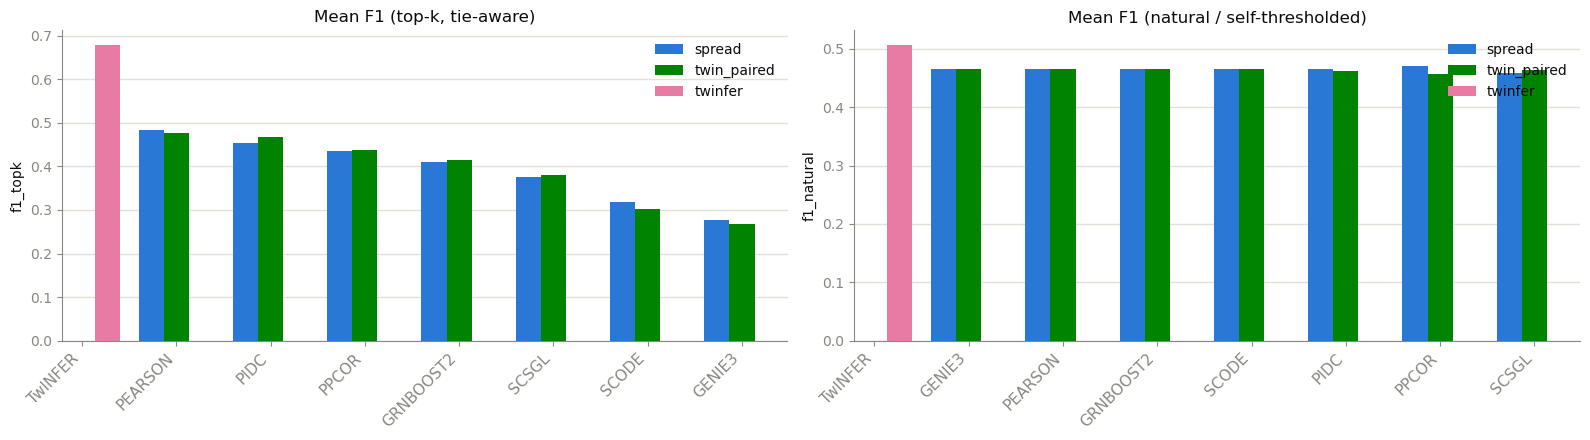

In [29]:
# Validated categorical palette (references/palette.md), fixed order, light-mode steps
SCHEME_COLORS = {"spread": "#2a78d6", "twin_paired": "#008300", "twinfer": "#e87ba4"}
SCHEME_ORDER = ["spread", "twin_paired", "twinfer"]
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"


def plot_metric_by_algorithm(metric: str, ax=None, title=None):
    pivot = results.groupby(["algorithm", "scheme"])[metric].mean().unstack("scheme")
    pivot = pivot.reindex(columns=[c for c in SCHEME_ORDER if c in pivot.columns])
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(9, 4.5))

    x = range(len(pivot))
    width = 0.8 / max(len(pivot.columns), 1)
    for i, scheme in enumerate(pivot.columns):
        offsets = [xi + (i - (len(pivot.columns) - 1) / 2) * width for xi in x]
        ax.bar(offsets, pivot[scheme], width=width, color=SCHEME_COLORS.get(scheme, INK_MUTED),
               label=scheme, zorder=3)

    ax.set_xticks(list(x))
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", color=INK_PRIMARY, fontsize=11)
    ax.set_ylabel(metric, color=INK_PRIMARY)
    ax.set_title(title or f"Mean {metric} by algorithm", color=INK_PRIMARY)
    ax.grid(axis="y", color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(INK_MUTED)
    ax.tick_params(colors=INK_MUTED)
    # Older matplotlib (3.0.x, installed in the BEELINE env) doesn't support
    # legend(labelcolor=...) -- added in 3.3. Set text color on the returned
    # Legend's text objects directly instead, which works on any version.
    legend = ax.legend(frameon=False)
    for text in legend.get_texts():
        text.set_color(INK_PRIMARY)

    if own_ax:
        fig.tight_layout()
        return fig


fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
plot_metric_by_algorithm("f1_topk", ax=axes[0], title="Mean F1 (top-k, tie-aware)")
plot_metric_by_algorithm("f1_natural", ax=axes[1], title="Mean F1 (natural / self-thresholded)")
fig.tight_layout()

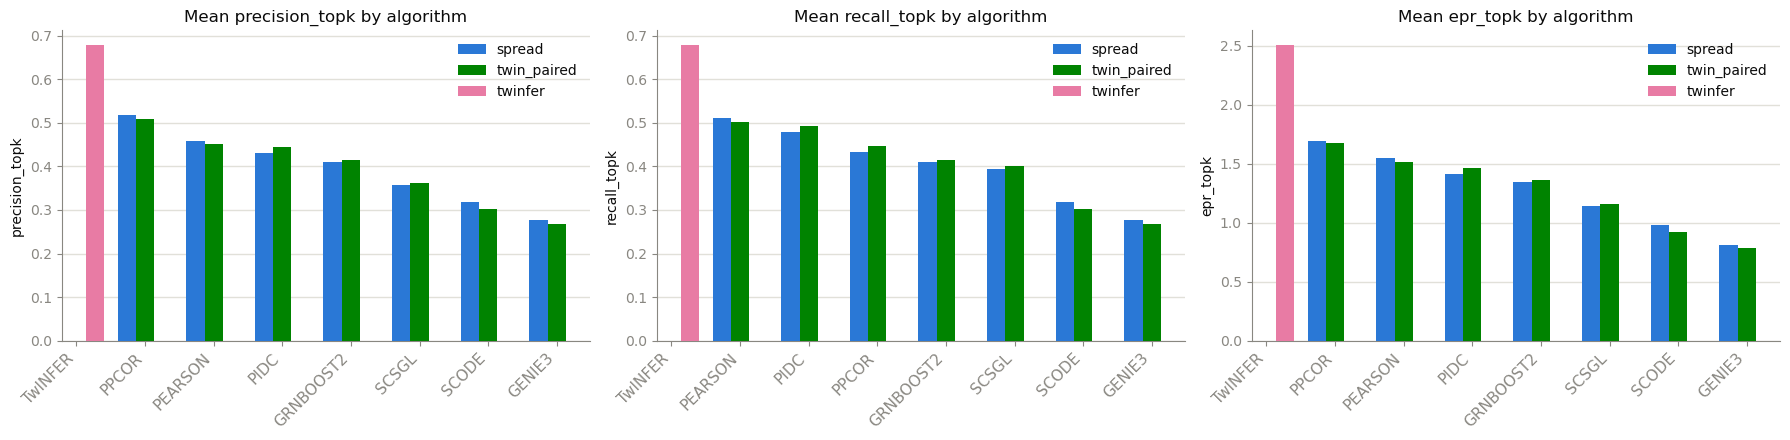

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_metric_by_algorithm("precision_topk", ax=axes[0])
plot_metric_by_algorithm("recall_topk", ax=axes[1])
plot_metric_by_algorithm("epr_topk", ax=axes[2])
fig.tight_layout()

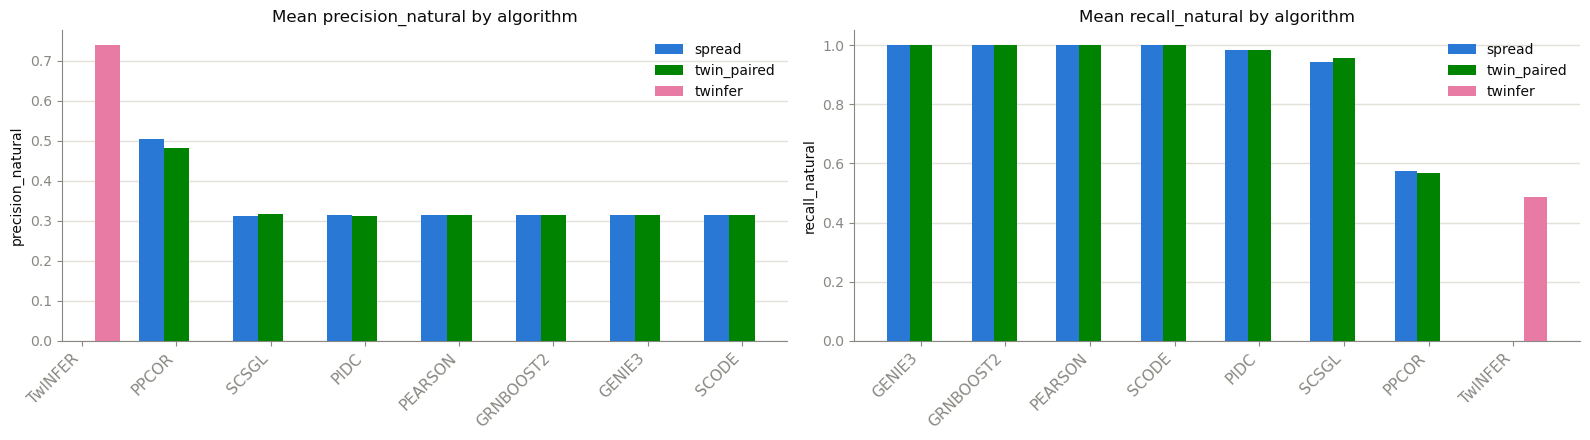

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
plot_metric_by_algorithm("precision_natural", ax=axes[0])
plot_metric_by_algorithm("recall_natural", ax=axes[1])
fig.tight_layout()

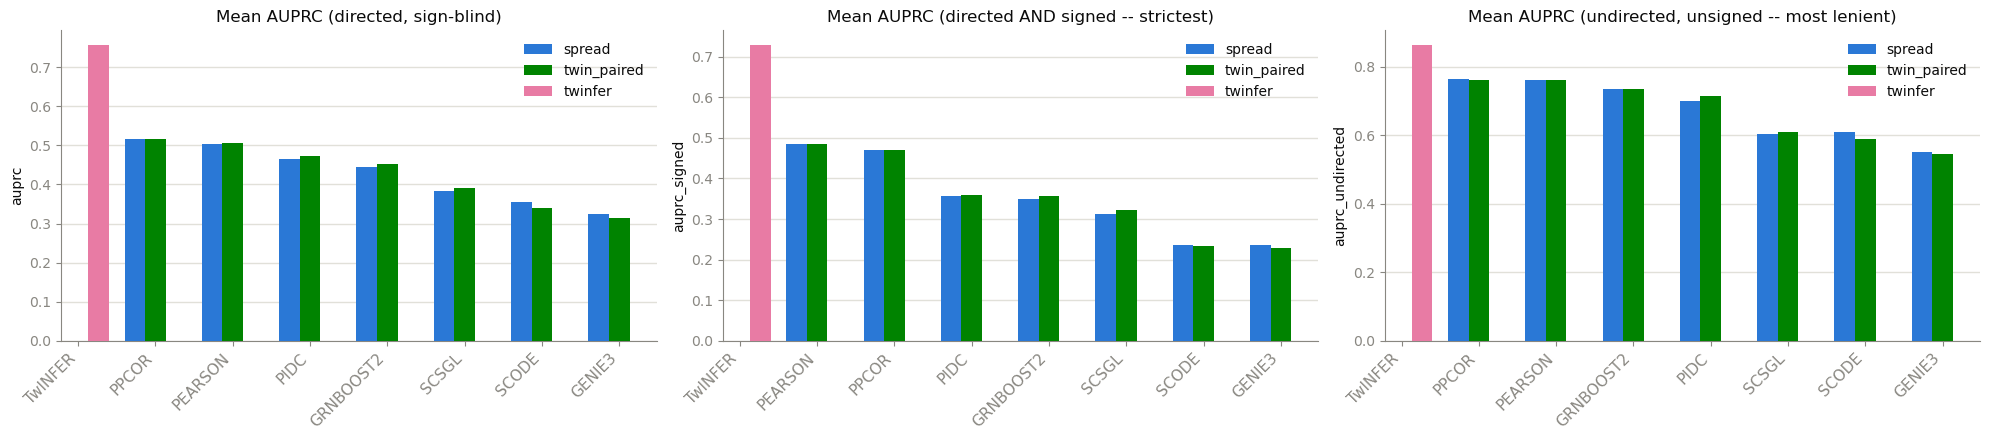

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
plot_metric_by_algorithm("auprc", ax=axes[0], title="Mean AUPRC (directed, sign-blind)")
plot_metric_by_algorithm("auprc_signed", ax=axes[1], title="Mean AUPRC (directed AND signed -- strictest)")
plot_metric_by_algorithm("auprc_undirected", ax=axes[2], title="Mean AUPRC (undirected, unsigned -- most lenient)")
fig.tight_layout()

## Distribution per individual dataset

One box (quartile spread across every algorithm x scheme x sim_rep combination evaluated on that dataset) plus jittered individual points per dataset, colored by scheme so the same categorical mapping used above still applies. This shows how much a metric varies *within* a single topology, not just its mean across topologies.

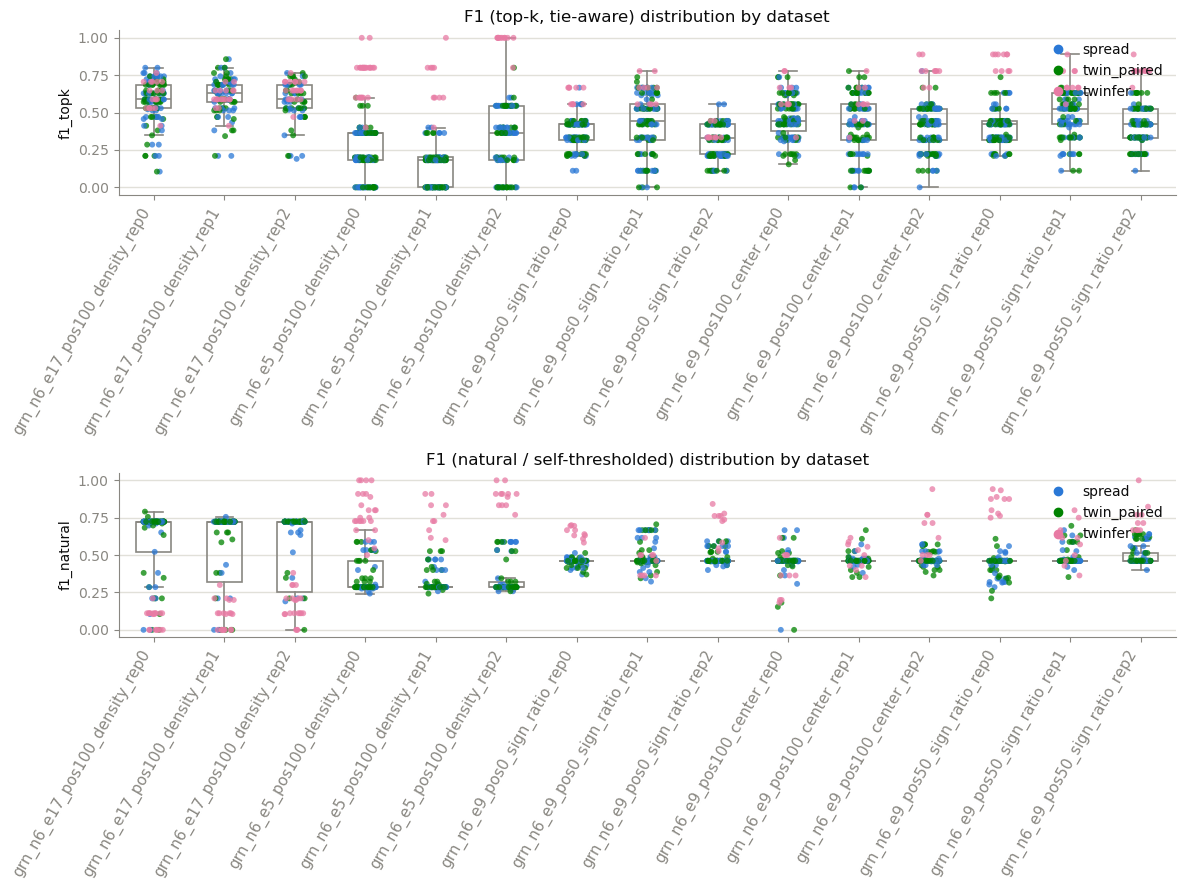

In [33]:
import numpy as np

# np.random.default_rng needs numpy>=1.17; this env pins numpy 1.15.4, so use
# the legacy RandomState API instead.
_rng = np.random.RandomState(0)


def plot_box_dot_by_dataset(metric: str, ax=None, title=None):
    dataset_ids = sorted(results["dataset_id"].unique())
    grouped = [
        results.loc[results["dataset_id"] == d, metric].dropna().values
        for d in dataset_ids
    ]

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(12, 5))

    positions = range(1, len(dataset_ids) + 1)
    bp = ax.boxplot(
        grouped, positions=list(positions), widths=0.5, showfliers=False,
        patch_artist=True,
    )
    for box in bp["boxes"]:
        box.set(facecolor="none", edgecolor=INK_MUTED, linewidth=1.2, zorder=2)
    for element in ["whiskers", "caps", "medians"]:
        for artist in bp[element]:
            artist.set(color=INK_MUTED, linewidth=1.2)

    # Jittered dots on top, colored by scheme (same mapping as the bar charts above)
    for pos, dataset_id in zip(positions, dataset_ids):
        subset = results[results["dataset_id"] == dataset_id].dropna(subset=[metric])
        jitter = _rng.uniform(-0.15, 0.15, size=len(subset))
        colors = subset["scheme"].map(SCHEME_COLORS).fillna(INK_MUTED)
        ax.scatter(
            pos + jitter, subset[metric],
            color=colors, s=18, alpha=0.75, zorder=3, linewidths=0,
        )

    ax.set_xticks(list(positions))
    ax.set_xticklabels(dataset_ids, rotation=60, ha="right", color=INK_PRIMARY, fontsize=11)
    ax.set_ylabel(metric, color=INK_PRIMARY)
    ax.set_title(title or f"{metric} distribution by dataset", color=INK_PRIMARY)
    ax.grid(axis="y", color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(INK_MUTED)
    ax.tick_params(colors=INK_MUTED)

    # Legend for scheme colors (dots aren't from ax.bar/scatter-with-label, so build handles manually)
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=s)
        for s, c in SCHEME_COLORS.items()
        if s in results["scheme"].unique()
    ]
    legend = ax.legend(handles=handles, frameon=False, loc="upper right")
    for text in legend.get_texts():
        text.set_color(INK_PRIMARY)

    if own_ax:
        fig.tight_layout()
        return fig


fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plot_box_dot_by_dataset("f1_topk", ax=axes[0], title="F1 (top-k, tie-aware) distribution by dataset")
plot_box_dot_by_dataset("f1_natural", ax=axes[1], title="F1 (natural / self-thresholded) distribution by dataset")
fig.tight_layout()

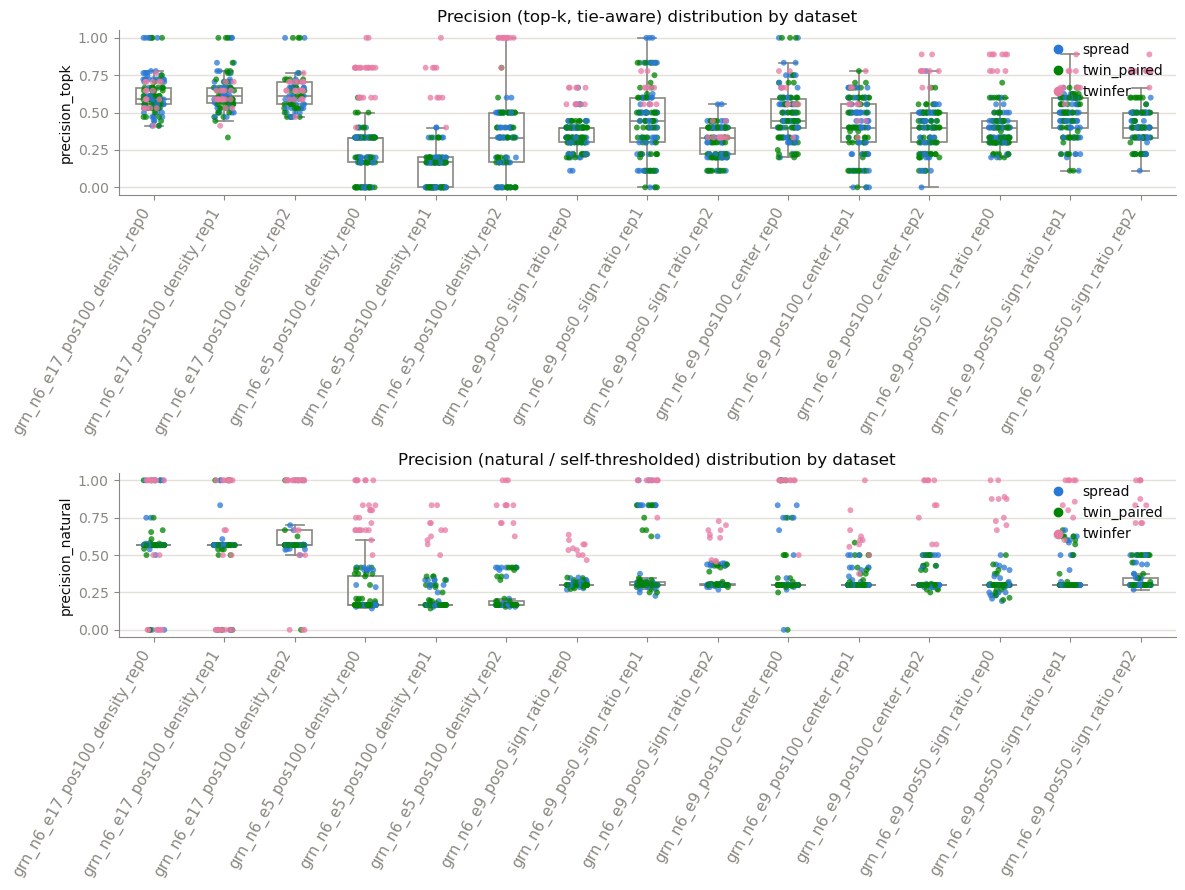

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plot_box_dot_by_dataset("precision_topk", ax=axes[0], title="Precision (top-k, tie-aware) distribution by dataset")
plot_box_dot_by_dataset("precision_natural", ax=axes[1], title="Precision (natural / self-thresholded) distribution by dataset")
fig.tight_layout()

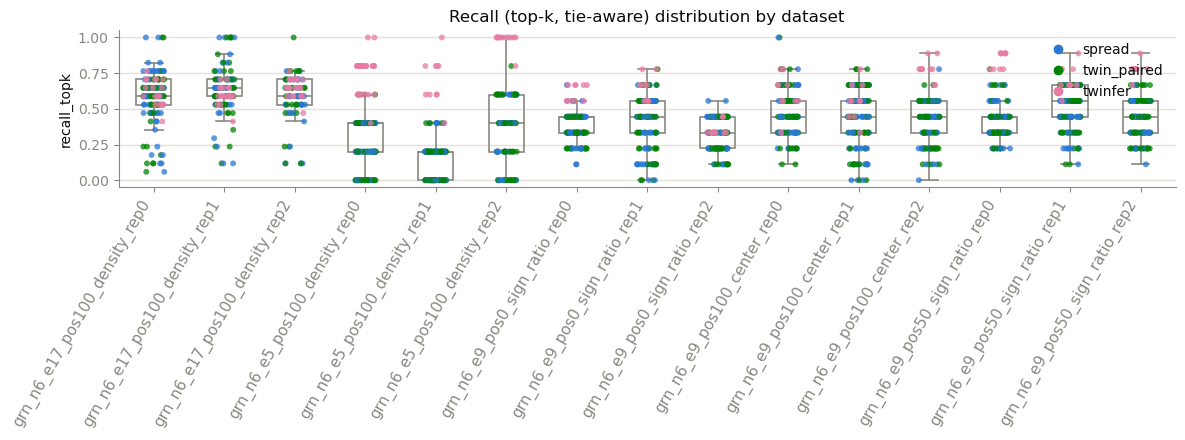

In [35]:
fig, axes = plt.subplots(1, 1, figsize=(12, 4.5))
plot_box_dot_by_dataset("recall_topk", ax=axes, title="Recall (top-k, tie-aware) distribution by dataset")
# plot_box_dot_by_dataset("recall_natural", ax=axes[1], title="Recall (natural / self-thresholded) distribution by dataset")
fig.tight_layout()

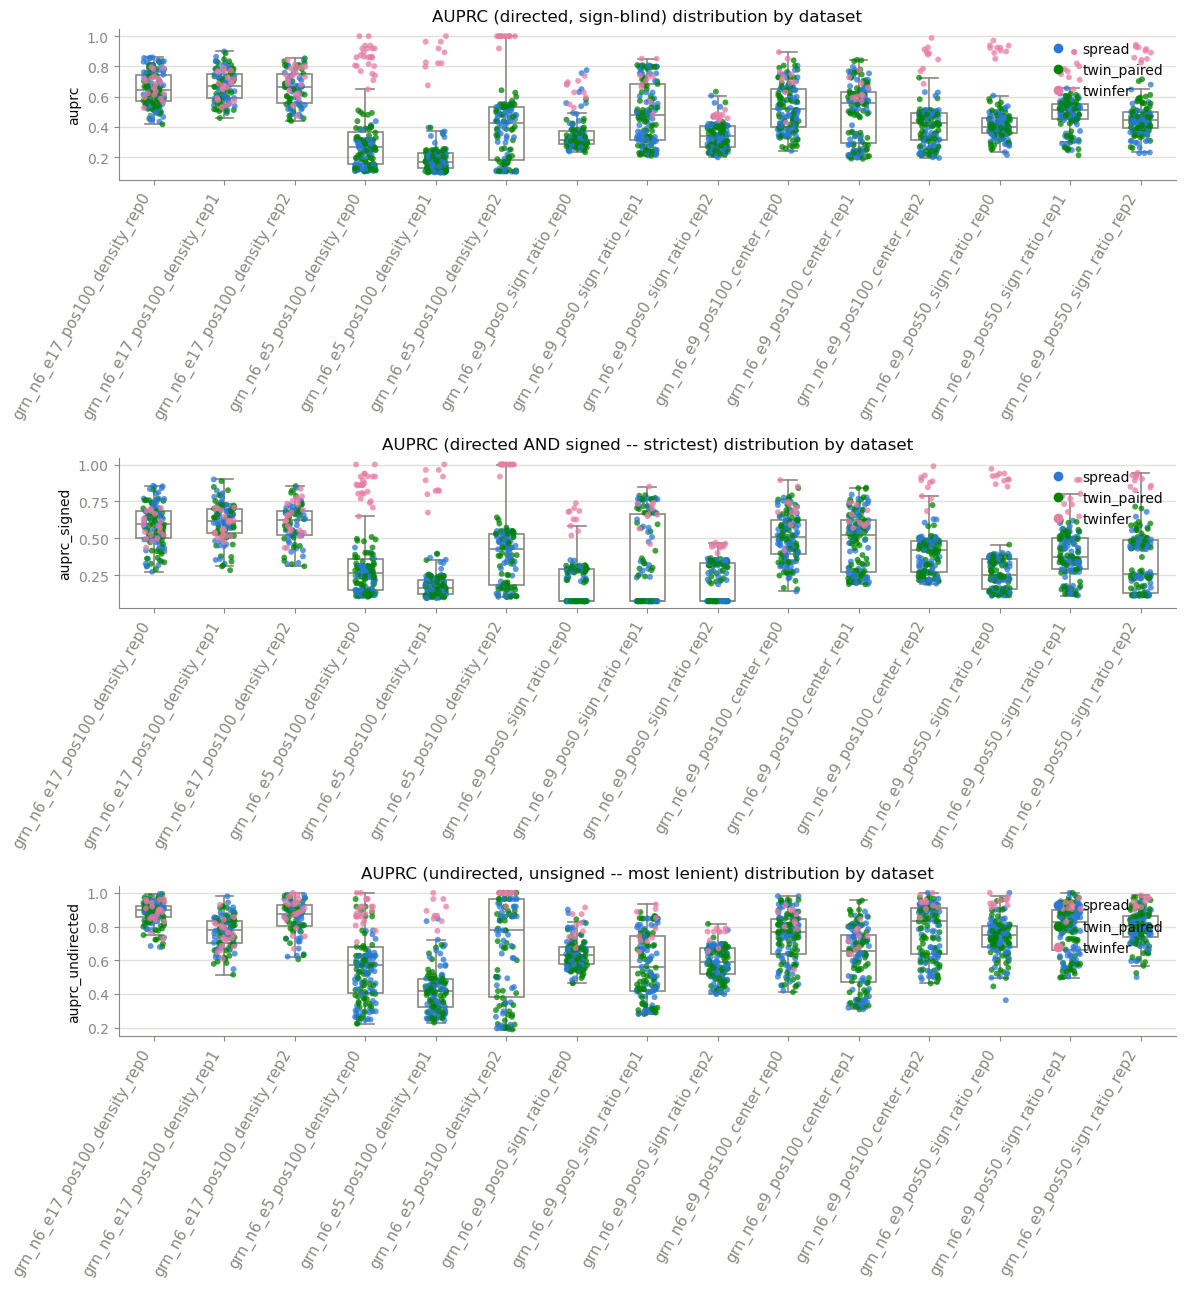

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(12, 13))
plot_box_dot_by_dataset("auprc", ax=axes[0], title="AUPRC (directed, sign-blind) distribution by dataset")
plot_box_dot_by_dataset("auprc_signed", ax=axes[1], title="AUPRC (directed AND signed -- strictest) distribution by dataset")
plot_box_dot_by_dataset("auprc_undirected", ax=axes[2], title="AUPRC (undirected, unsigned -- most lenient) distribution by dataset")
fig.tight_layout()

## Heatmap: every method, identified

The box/dot plots above show the spread across algorithms per dataset, but don't identify *which* dot belongs to *which* algorithm. This heatmap makes algorithm identity an explicit axis: rows = algorithm, columns = dataset (averaged across sim_reps), color = metric value, for a single sampling scheme at a time -- set `HEATMAP_SCHEME` below to `"spread"` or `"twin_paired"` to choose which (TwINFER is folded in either way, since it isn't run through a sampling scheme). Color here does a *magnitude* job, not an identity job, so it uses a single-hue-family sequential ramp (`flare`, light -> dark) rather than the categorical palette used elsewhere in this notebook -- linear scaling from true zero, no gamma stretch. Cell values are annotated directly since exact numbers matter for this kind of comparison. Two extra columns are appended on the right of every heatmap: **Average** (mean of that row's metric across all shown datasets -- the same quantity rows are already sorted by) and **Rank** (that average's rank among the shown algorithms, 1 = best). The Rank column has no color fill since rank position, not magnitude, is what it encodes.

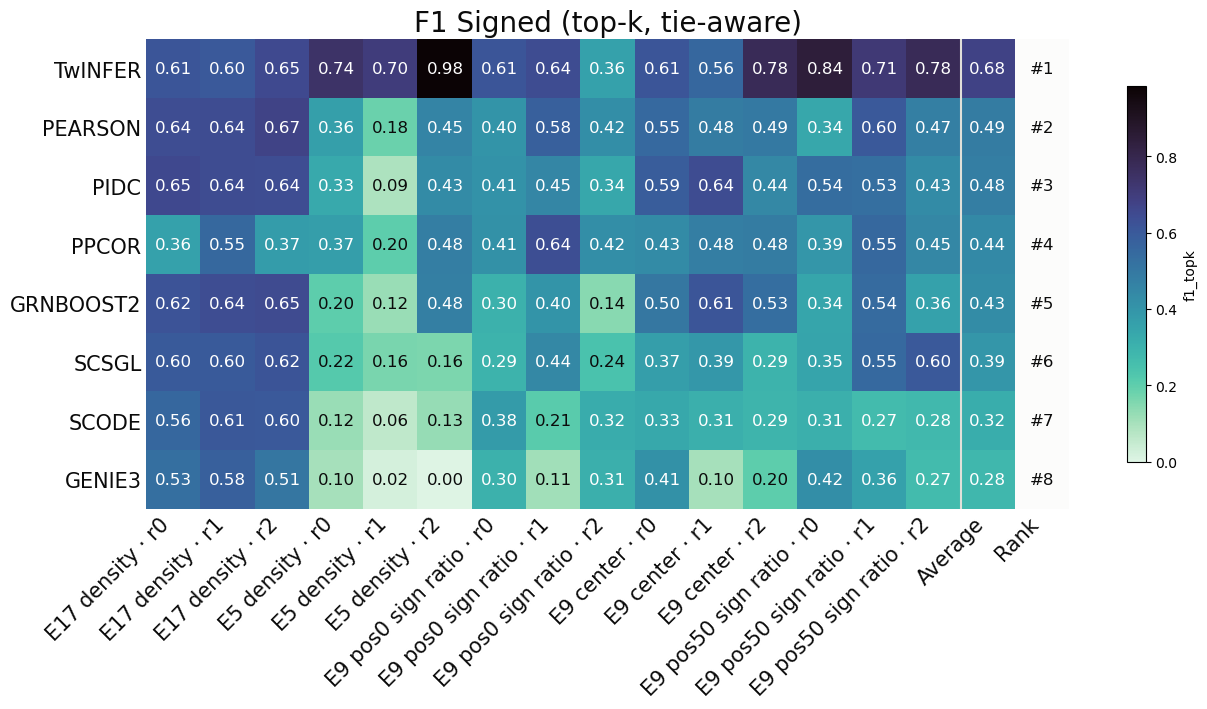

In [42]:
import seaborn as sns  # registers the "flare" colormap with matplotlib
from matplotlib.colors import Normalize

# Single-hue-family sequential colormap for magnitude encoding
HEATMAP_CMAP = sns.color_palette("mako_r", as_cmap=True)

# Neutral background for the Rank column, which is deliberately unfilled --
# rank position isn't a magnitude, so it shouldn't be pulled from the same
# color scale as the metric cells. Matches the light chart surface used
# elsewhere in this notebook's palette.
HEATMAP_SURFACE = "#fcfcfb"

# Change to "spread" or "twin_paired" -- controls which sampling scheme's
# heatmap gets rendered by every plot_heatmap_by_algorithm_dataset(...) call
# below.
HEATMAP_SCHEME = "twin_paired"

# Every dataset_id is "grn_n6_e{edges}_pos{pos}_{variant}_rep{rep}" -- n is
# fixed at 6 across the whole sweep, so it's dropped from the display label;
# pos is only informative for the sign_ratio variant (it's constant at 100
# for density/center), so it's only shown there.
DATASET_LABEL_RE = re.compile(
    r"^grn_n\d+_e(?P<e>\d+)(?:_pos(?P<pos>\d+))?_(?P<variant>density|sign_ratio|center)_rep(?P<rep>\d+)$"
)


def prettify_dataset_id(dataset_id: str) -> str:
    m = DATASET_LABEL_RE.match(dataset_id)
    if not m:
        return dataset_id
    pos_label = f"pos{m['pos']} " if m["variant"] == "sign_ratio" else ""
    return f"E{m['e']} {pos_label}{m['variant'].replace('_', ' ')} \u00b7 r{m['rep']}"


def _label_color_for(val: float, norm, cmap) -> str:
    # Pick white vs. ink by the actual rendered cell color's luminance rather
    # than assuming which end of the ramp is dark -- keeps this correct
    # regardless of which colormap HEATMAP_CMAP is set to.
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "#ffffff" if luminance < 0.6 else INK_PRIMARY


def plot_heatmap_by_algorithm_dataset(metric: str, scheme: str = None, ax=None, title=None, norm=None):
    # TwINFER isn't run through either sampling scheme (it's its own method
    # operating on the raw twin-simulation data directly), so its row is the
    # same regardless of scheme -- fold it in for direct row-by-row
    # comparison against the BEELINE algorithms instead of segregating it.
    scheme = scheme or HEATMAP_SCHEME
    subset = results[(results["scheme"] == scheme) | (results["algorithm"] == "TwINFER")]
    pivot = subset.groupby(["algorithm", "dataset_id"])[metric].mean().unstack("dataset_id")

    # Average across datasets and each row's rank by that average (1 = best)
    # -- computed before sorting so the rank doesn't just restate row order.
    row_avg = pivot.mean(axis=1)
    row_rank = row_avg.rank(ascending=False, method="min").astype(int)
    pivot = pivot.loc[row_avg.sort_values(ascending=False).index]
    row_avg = row_avg.loc[pivot.index]
    row_rank = row_rank.loc[pivot.index]

    n_dataset_cols = pivot.shape[1]

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(0.6 * (n_dataset_cols + 2) + 3, 0.4 * len(pivot.index) + 4))

    # Anchored at true zero (norm.vmin == 0), plain linear scaling to vmax --
    # no gamma stretch, so cell color is directly proportional to the metric.
    # vmax is taken from the dataset cells only; Average can't exceed that.
    if norm is None:
        vmax = float(pivot.values[~pd.isna(pivot.values)].max())
        norm = Normalize(vmin=0.0, vmax=vmax)

    # Append Average (colored, same scale as the metric) and Rank (left as
    # NaN so it renders as a flat, unfilled column -- rank position isn't a
    # magnitude and shouldn't be pulled from the metric's color scale).
    grid = np.hstack([
        pivot.values,
        row_avg.values.reshape(-1, 1),
        np.full((len(pivot), 1), np.nan),
    ])

    display_cmap = HEATMAP_CMAP.copy()
    display_cmap.set_bad(HEATMAP_SURFACE)

    im = ax.imshow(grid, cmap=display_cmap, aspect="auto", norm=norm)

    for i in range(grid.shape[0]):
        for j in range(n_dataset_cols + 1):  # dataset columns + Average
            val = grid[i, j]
            if pd.isna(val):
                continue
            label_color = _label_color_for(val, norm, HEATMAP_CMAP)
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=12, color=label_color)
        # Rank column: plain text on the unfilled background, no magnitude coloring.
        ax.text(n_dataset_cols + 1, i, f"#{row_rank.iloc[i]}", ha="center", va="center",
                 fontsize=12, color=INK_PRIMARY)

    # Separator between the per-dataset cells and the Average/Rank summary columns.
    ax.axvline(n_dataset_cols - 0.5, color=GRIDLINE, linewidth=1.5)

    ax.set_xticks(range(grid.shape[1]))
    ax.set_xticklabels(
        [prettify_dataset_id(c) for c in pivot.columns] + ["Average", "Rank"],
        rotation=45, ha="right", color=INK_PRIMARY, fontsize=15,
    )
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=INK_PRIMARY, fontsize=15)
    ax.set_title(title or f"{metric} -- {scheme}", color=INK_PRIMARY, fontsize=20)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    if own_ax:
        fig.colorbar(im, ax=ax, shrink=0.8, label=metric)
        fig.tight_layout()
        return fig
    return im


plot_heatmap_by_algorithm_dataset("f1_topk", title=f"F1 Signed (top-k, tie-aware)");

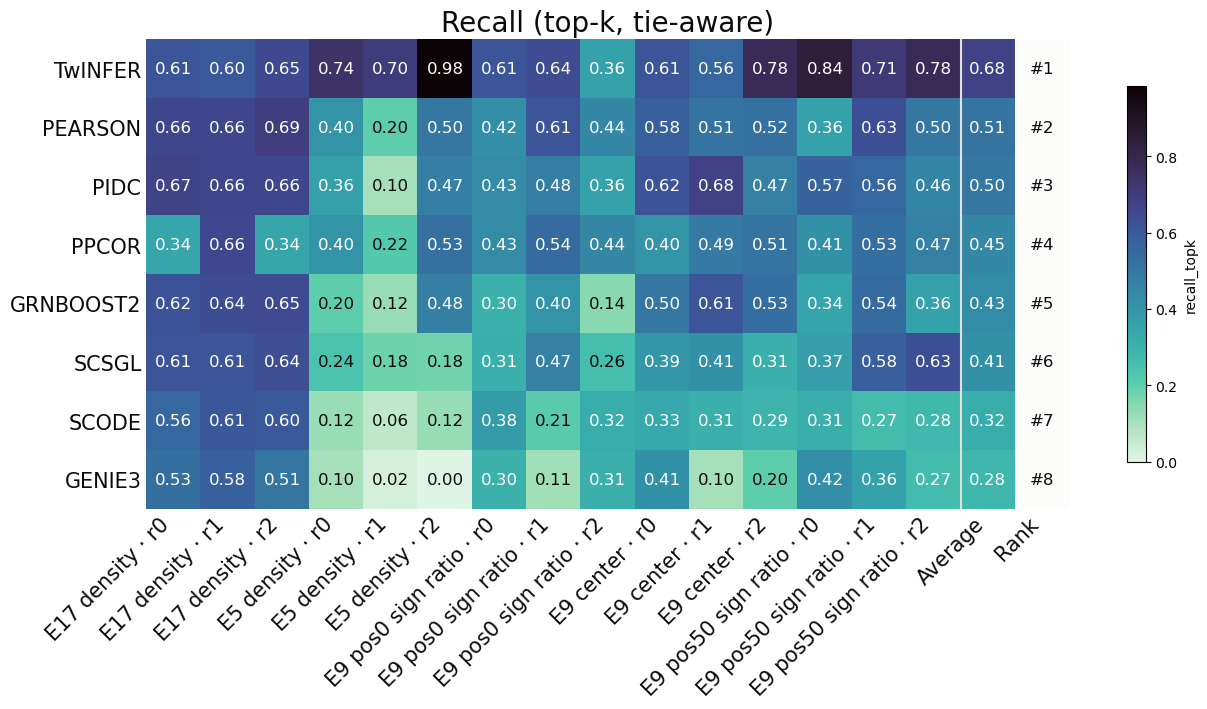

In [38]:
plot_heatmap_by_algorithm_dataset("recall_topk", title=f"Recall (top-k, tie-aware)");

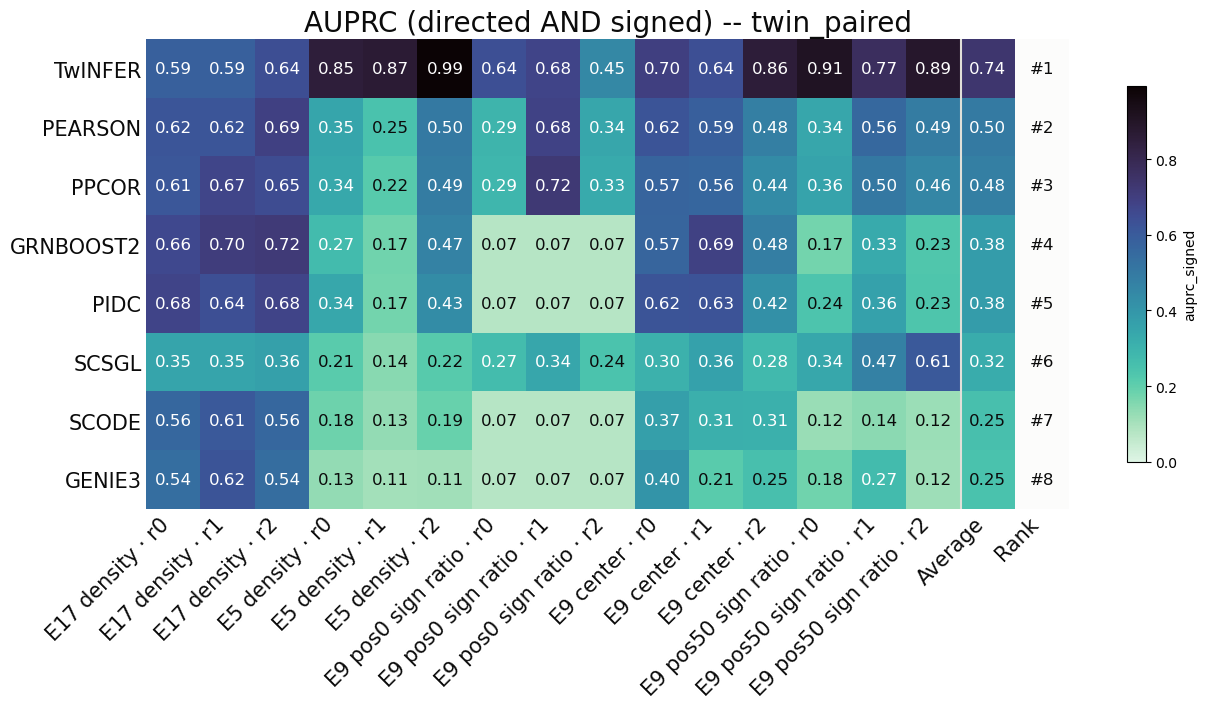

In [39]:
plot_heatmap_by_algorithm_dataset("auprc_signed", title=f"AUPRC (directed AND signed) -- {HEATMAP_SCHEME}");

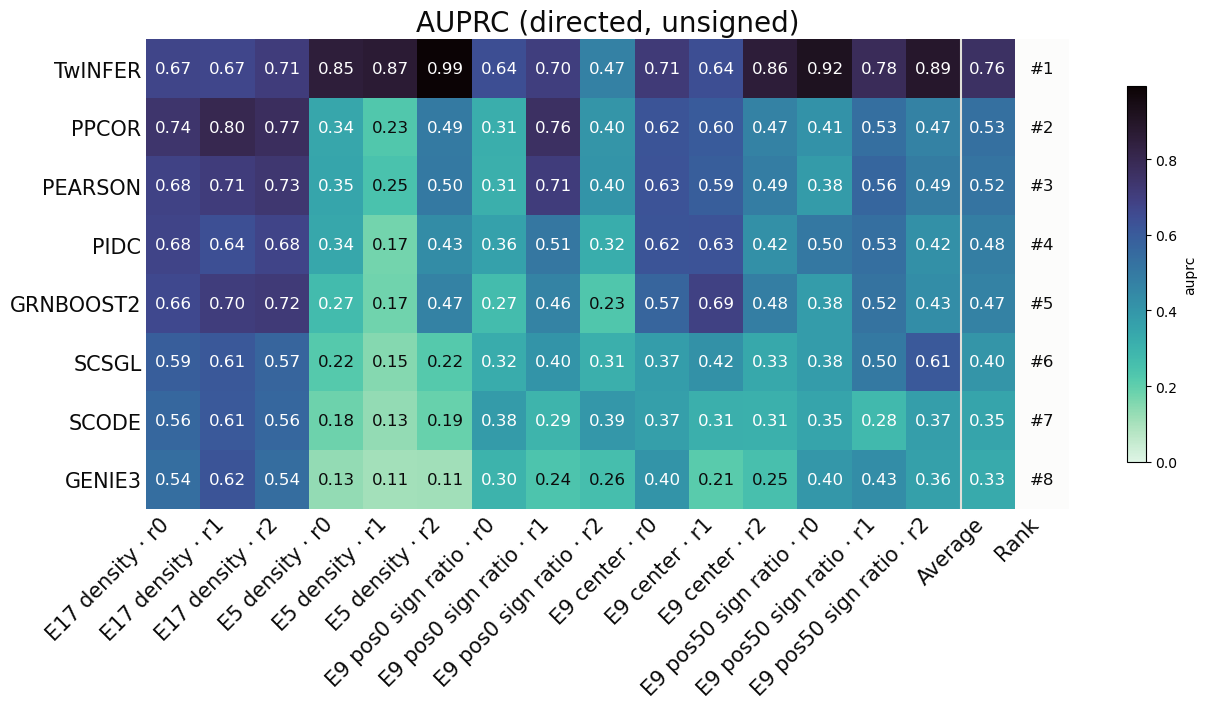

In [40]:
plot_heatmap_by_algorithm_dataset("auprc", title=f"AUPRC (directed, unsigned)");

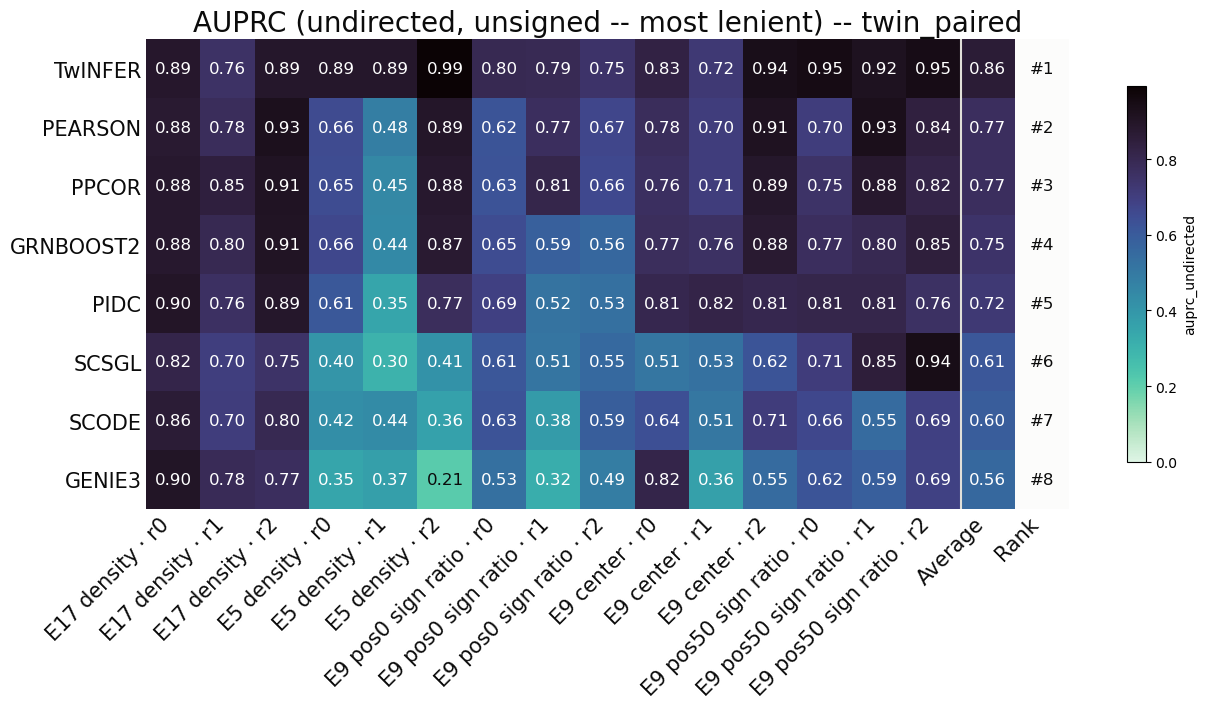

In [41]:
plot_heatmap_by_algorithm_dataset("auprc_undirected", title=f"AUPRC (undirected, unsigned -- most lenient) -- {HEATMAP_SCHEME}");

## Notes

- **EPR** (Early Precision Ratio) is `precision_topk / random_baseline_precision` -- values above 1 mean better than random chance for that dataset's edge density; included since it's directly comparable to BEELINE's own published numbers.
- Compare `n_selected_natural` to `n_true_edges` per algorithm in the summary table above: if they're close, `f1_topk` and `f1_natural` should roughly agree; a big gap between the two F1 columns for a given algorithm is the signal that it's the "outputs its own fixed network" type, and `f1_natural` is the fairer number to cite for it.
- Algorithms with `should_run: [False]` in the config (e.g. LEAP, SINCERITIES against `twin_paired`) simply won't have `rankedEdges.csv` files and are silently absent from these tables rather than erroring.
- If `BLRunner.py`'s per-runner error handling caused some (dataset, run, algorithm) combination to fail outright, it also won't appear here -- cross-check against the "N of M run(s) failed" summary `BLRunner.py` prints at the end of a benchmark pass.
- **`_signed` and `_undirected` columns**: three strictness levels are now computed side by side for every algorithm -- the original columns (directed, sign-blind), `_signed` (directed AND signed -- any mismatch is incorrect, the strictest), and `_undirected` (existence only, ignoring both direction and sign -- the most lenient). Expect `precision_undirected >= precision >= precision_signed` for a given algorithm/threshold, since each step only relaxes what counts as a match. For TwINFER, all three `auprc*` columns are real (computed from `ranked_edge_list` in `network_sweep_analysis.ipynb`); the threshold-based `precision_topk_signed`/`recall_topk_signed`/etc. columns are still `NaN` there (see the markdown cell above "Two additional comparison strictness levels").